# Análise - Vitórias das Escuderias na Formula 1


##  1. Introdução

A Fórmula 1, principal categoria do automobilismo mundial, possui um histórico extenso de corridas e construtores. Com base em dados históricos desde 1950, esta análise visa identificar as escuderias com maior número de vitórias, bem como compreender como essas vitórias se distribuíram ao longo das décadas.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Identificar as equipes (construtores) com o maior número de vitórias desde 1950;

    - Analisar a distribuição dessas vitórias por década: 1950s, 1960s, ..., até 2020s.


## 3. Metodologia
Inicialmente, foram utilizadas três bases de dados principais:

    - results.csv: Contém os resultados das corridas (inclusive posição de chegada);
    - constructors.csv: Dados sobre as equipes (construtores);
    - races.csv: Informações sobre cada corrida, incluindo o ano.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [3]:
import pandas as pd

# Carregandos as bases
resultados = pd.read_csv("results.csv", delimiter=",")
construtores = pd.read_csv("constructors.csv", delimiter=",")
corridas = pd.read_csv("races.csv", delimiter=",")

# Filtrando apenas os vencedores (posição 1 em cada corrida)
vencedores = resultados[resultados['positionOrder'] == 1]

# Juntando os dados com informações dos construtores
vencedores = vencedores.merge(construtores, on="constructorId", how="left")

# Adicionando o ano da corrida
vencedores = vencedores.merge(corridas[["raceId", "year"]], on="raceId", how="left")

# Criando uma nova coluna para representar a década
vencedores["decade"] = (vencedores["year"] // 10) * 10

## 4. Análise de Dados

#### 4.1 Total de Vitórias por Construtor

A contagem total de vitórias por equipe (construtor) foi realizada com base nas corridas em que o construtor terminou na primeira posição (positionOrder == 1):

In [4]:
total_vitorias = vencedores["name"].value_counts().reset_index()
total_vitorias.columns = ["constructor", "total_wins"]
print(total_vitorias)

        constructor  total_wins
0           Ferrari         249
1           McLaren         185
2          Mercedes         129
3          Red Bull         122
4          Williams         114
5        Team Lotus          45
6           Renault          35
7          Benetton          27
8           Brabham          23
9           Tyrrell          23
10     Lotus-Climax          22
11              BRM          17
12    Cooper-Climax          12
13       Alfa Romeo          11
14       Lotus-Ford          11
15          Vanwall          10
16       Matra-Ford           9
17           Ligier           9
18         Maserati           9
19    Brabham-Repco           8
20            Brawn           8
21     Kurtis Kraft           5
22           Jordan           4
23     McLaren-Ford           4
24           Watson           3
25            March           3
26            Honda           3
27             Wolf           3
28   Brabham-Climax           2
29         Lotus F1           2
30      

Essa tabela fornece um ranking dos construtores mais vitoriosos da história da Fórmula 1 desde 1950, permitindo identificar o domínio histórico de determinadas equipes.

#### 4.2 Vitórias por Década

Para compreender como o sucesso das equipes evoluiu ao longo do tempo, a análise foi segmentada por décadas:

In [5]:
vitorias_por_decada = vencedores.groupby(["decade", "name"]).size().reset_index(name="wins")
print(vitorias_por_decada)

    decade           name  wins
0     1950     Alfa Romeo    11
1     1950            BRM     1
2     1950         Cooper     2
3     1950  Cooper-Climax     5
4     1950        Epperly     2
..     ...            ...   ...
77    2020        Ferrari    10
78    2020        McLaren     7
79    2020       Mercedes    27
80    2020   Racing Point     1
81    2020       Red Bull    60

[82 rows x 3 columns]


Essa segmentação por década nos permite observar, por exemplo, se o domínio de uma equipe foi concentrado em um período específico ou distribuído ao longo do tempo. Também facilita a identificação de mudanças de hegemonia entre décadas.

## 5. Conclusão

A análise realizada permite obter uma visão clara da evolução histórica da competitividade entre as equipes na Fórmula 1. Dentre os principais aprendizados:

    - Algumas equipes acumulam vitórias de forma consistente ao longo de várias décadas, demonstrando estabilidade e           investimento contínuo em desempenho;

    - Outras equipes possuem picos de desempenho concentrados em uma única década, refletindo períodos específicos de inovação técnica ou vantagem competitiva;

    - A análise por década também revela transições de domínio, como a ascensão de novas equipes e o declínio de outras.

C:\Users\flavi\AppData\Local\Temp\ipykernel_19380\806119990.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)
C:\Users\flavi\AppData\Local\Temp\ipykernel_19380\806119990.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)
C:\Users\flavi\AppData\Local\Temp\ipykernel_19380\806119990.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)


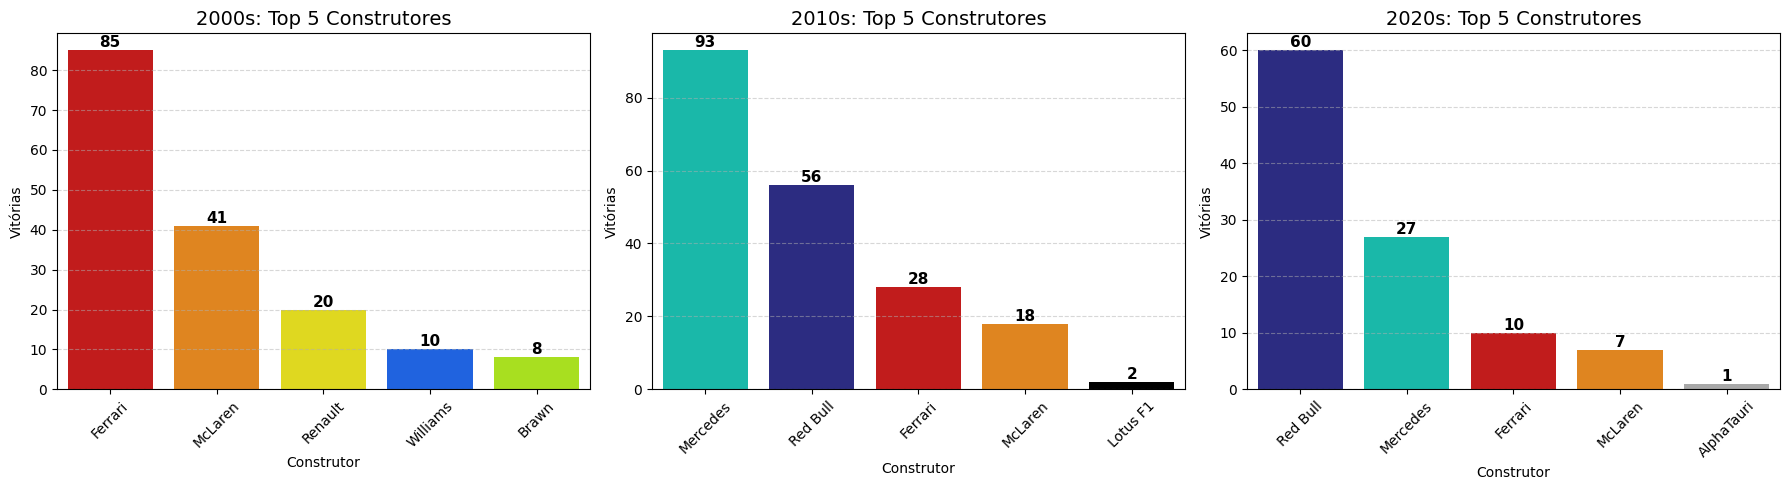

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionário com cores personalizadas por escuderia
cores_personalizadas = {
    "Ferrari": "#DC0000",       # Vermelho Ferrari
    "McLaren": "#FF8700",       # Laranja McLaren
    "Renault": "#FFF500",       # Amarelo
    "Williams": "#005AFF",      # Azul
    "Brawn": "#B6FF00",         # Verde Claro
    "Red Bull": "#1E1E8F",      # Azul Escuro
    "Mercedes": "#00D2BE",      # Ciano
    "Lotus F1": "#000000",         # Preto
    "AlphaTauri": "#A8A8A8",   # Cinza
}

# Filtrar décadas e obter os 5 mais vitoriosos por década
decadas = [2000, 2010, 2020]
top5_por_decada = {}

# Guardar todas as equipes envolvidas
construtores_utilizados = set()

for decada in decadas:
    top5 = (
        vitorias_por_decada[vitorias_por_decada["decade"] == decada]
        .sort_values(by="wins", ascending=False)
        .head(5)
    )
    top5_por_decada[decada] = top5
    construtores_utilizados.update(top5["name"].tolist())

# Verifica se há escuderias não listadas manualmente
escuderias_faltando = construtores_utilizados - set(cores_personalizadas.keys())
if escuderias_faltando:
    print("⚠️ Escuderias sem cor definida:", escuderias_faltando)

# Plotando os gráficos
plt.figure(figsize=(18, 5))

for i, decada in enumerate(decadas, 1):
    dados = top5_por_decada[decada]

    # Obter lista de cores na ordem dos construtores
    cores = [cores_personalizadas.get(nome, "#888888") for nome in dados["name"]]

    # Subplot
    plt.subplot(1, 3, i)
    ax = sns.barplot(data=dados, x="name", y="wins", palette=cores)

    plt.title(f"{decada}s: Top 5 Construtores", fontsize=14)
    plt.xlabel("Construtor")
    plt.ylabel("Vitórias")
    plt.xticks(rotation=45)

    # Adicionar valores nas colunas
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

    plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


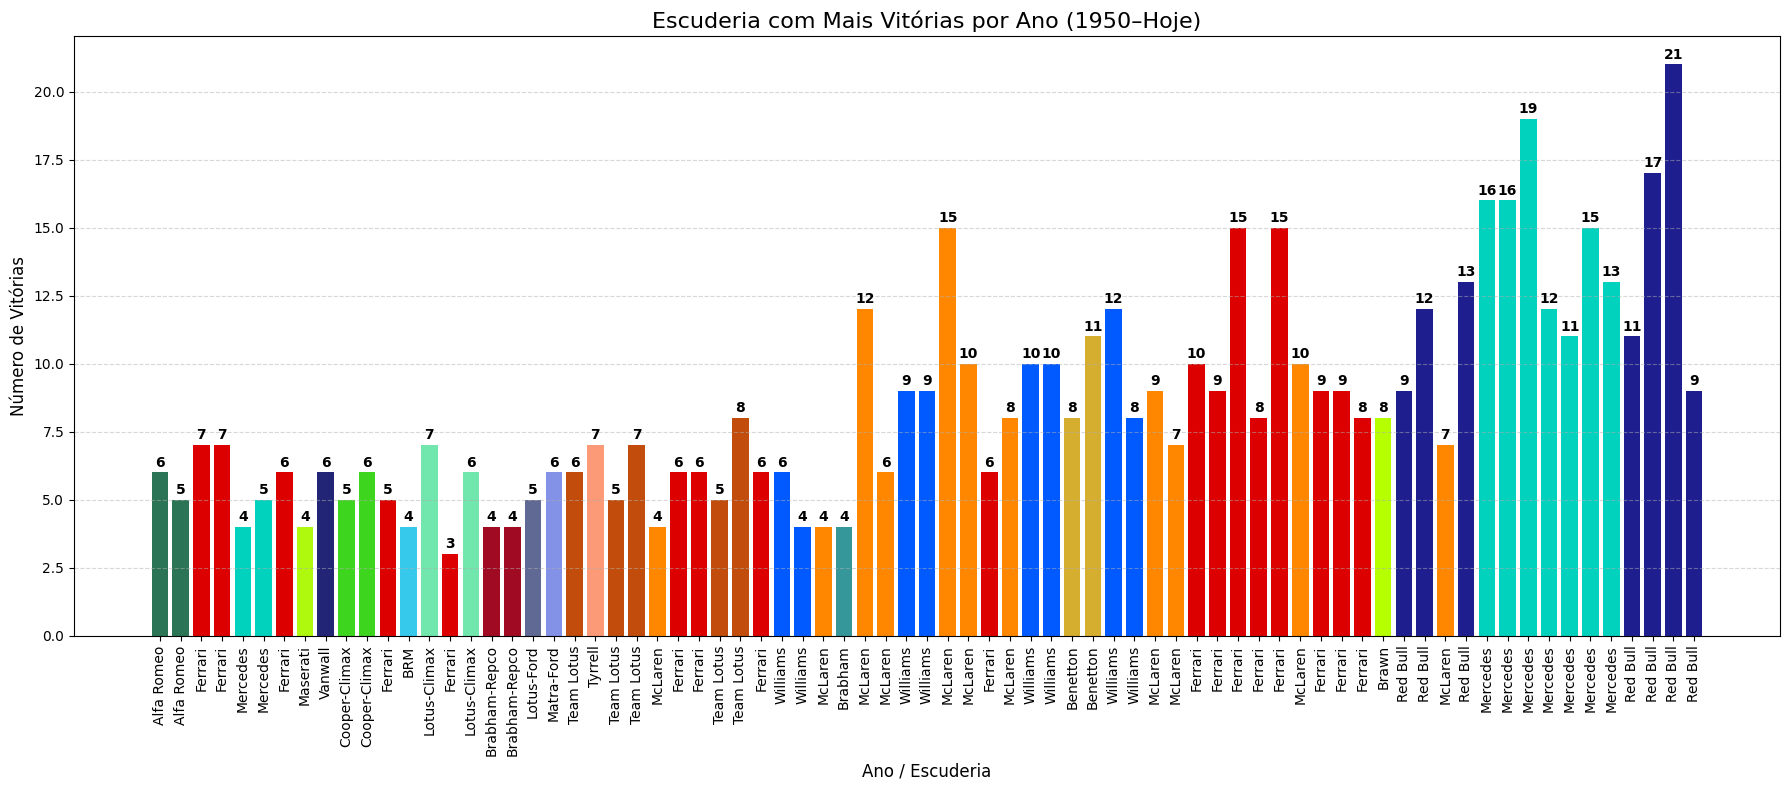

In [15]:
import matplotlib.pyplot as plt

# Agrupar por ano e escuderia, contar vitórias (já feito)
vitorias_ano = vencedores.groupby(["year", "name"]).size().reset_index(name="wins")

# Para cada ano, pegar a escuderia com mais vitórias
max_vitorias_por_ano = vitorias_ano.loc[vitorias_ano.groupby("year")["wins"].idxmax()]

# Ordenar pelo ano (por segurança)
max_vitorias_por_ano = max_vitorias_por_ano.sort_values("year")

# Preparar o gráfico
fig, ax = plt.subplots(figsize=(18, 8))

# Barras: uma barra por ano, altura = número de vitórias da escuderia que mais venceu
bars = ax.bar(
    max_vitorias_por_ano["year"],
    max_vitorias_por_ano["wins"],
    color=[cores_personalizadas.get(esc, "#777777") for esc in max_vitorias_por_ano["name"]]
)

# Colocar o nome da escuderia como label abaixo do eixo x, usando ticks personalizados
ax.set_xticks(max_vitorias_por_ano["year"])
ax.set_xticklabels(max_vitorias_por_ano["name"], rotation=90)

# Colocar o número de vitórias acima da barra
for bar, vitoria in zip(bars, max_vitorias_por_ano["wins"]):
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.1,
        str(vitoria),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Personalização do gráfico
plt.title("Escuderia com Mais Vitórias por Ano (1950–Hoje)", fontsize=16)
plt.xlabel("Ano / Escuderia", fontsize=12)
plt.ylabel("Número de Vitórias", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
